## Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from ngboost import NGBRegressor, scores
from ngboost.distns import Normal
from scipy.stats import norm
import joblib
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

def willmott_index(y_true, y_pred):
    numerator = np.sum((y_pred - y_true)**2)
    denominator = np.sum((np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true))) ** 2)
    return 1 - (numerator / denominator)


def percent_bias(y_true, y_pred):
    return 100 * np.sum(y_pred - y_true) / np.sum(y_true)


def rmse_ci(y_true, lower, upper):
    error = np.where(y_true < lower, lower - y_true, np.where(y_true > upper, y_true - upper, 0))
    return np.sqrt(np.mean(error**2))


def mae_ci(y_true, lower, upper):
    error = np.where(y_true < lower, lower - y_true, np.where(y_true > upper, y_true - upper, 0))
    return np.mean(np.abs(error))


def crps_normal(y, mu, sigma):
    z = np.absolute(y - mu) / sigma
    phi = norm.pdf(z)
    Phi = norm.cdf(z)
    crps = sigma * (z * (2 * Phi - 1) + 2 * phi - 1/np.sqrt(np.pi))
    return np.mean(crps)


class NGBoostPipeline:
    def __init__(self, csv_path, ngb_params, model_path):
        self.csv_path = csv_path
        self.ngb_params = ngb_params
        self.model_path = model_path

    def load_data(self):
        self.data = pd.read_csv(self.csv_path, parse_dates=['time'], index_col='time')

    def feature_engineering(self):
        data = self.data
        cols = list(data.columns)
        shifts = []
        for i in range(1, 13):
            col_map = dict(zip(cols, [c + f'-{i}' for c in cols]))
            shifts.append(data.shift(i).rename(columns=col_map))
        X = pd.concat(shifts, axis=1)
        X.dropna(inplace=True)
        X = X.iloc[::4]
        X['Day of Year'] = X.index.day_of_year
        X['Year'] = X.index.year
        X['Month'] = X.index.month
        X['day_sin'] = np.sin(2 * np.pi * X['Day of Year'] / 365)
        X['day_cos'] = np.cos(2 * np.pi * X['Day of Year'] / 365)
        X['month_sin'] = np.sin(2 * np.pi * X['Month'] / 12)
        X.drop(['Day of Year', 'Month'], axis=1, inplace=True)
        self.X = X

        y = data['temperature_2m (°C)'].iloc[12:]
        Y = pd.concat([
            y,
            y.shift(-1).rename('temperature_2m (°C)+1'),
            y.shift(-2).rename('temperature_2m (°C)+2'),
            y.shift(-3).rename('temperature_2m (°C)+3')
        ], axis=1)
        Y = Y.iloc[::4]
        self.Y = Y

    def split_scale(self, train_start, train_end, test_start, test_end):
        self.X_train = self.X.loc[train_start:train_end]
        self.y_train = self.Y.loc[train_start:train_end]
        self.X_test = self.X.loc[test_start:test_end]
        self.y_test = self.Y.loc[test_start:test_end]

        self.scaler_X = StandardScaler()
        self.scaler_Y = StandardScaler()

        self.X_train_scaled = self.scaler_X.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler_X.transform(self.X_test)
        self.y_train_scaled = self.scaler_Y.fit_transform(self.y_train)
        self.y_test_scaled = self.scaler_Y.transform(self.y_test)

    def train(self):
        base = NGBRegressor(**self.ngb_params)
        self.model = MultiOutputRegressor(base)
        self.model.fit(self.X_train_scaled, self.y_train_scaled)
        joblib.dump(self.model, self.model_path)

    def predict(self):
        dists = [est.pred_dist(self.X_test_scaled) for est in self.model.estimators_]
        self.pred_mean = self.scaler_Y.inverse_transform(np.column_stack([d.loc for d in dists]))
        self.pred_std = np.column_stack([d.scale for d in dists]) * self.scaler_Y.scale_
        self.lower_95, self.upper_95 = norm.interval(0.95, self.pred_mean, self.pred_std)
        self.lower_99, self.upper_99 = norm.interval(0.99, self.pred_mean, self.pred_std)

    def evaluate(self):
        self.rmse_point = root_mean_squared_error(self.y_test.values, self.pred_mean)
        self.mae_point = mean_absolute_error(self.y_test.values, self.pred_mean)
        self.r2_point = r2_score(self.y_test.values, self.pred_mean)
        self.mape_point = mean_absolute_percentage_error(self.y_test.values, self.pred_mean)
        self.willmott = willmott_index(self.y_test.values, self.pred_mean)
        self.pbias = percent_bias(self.y_test.values, self.pred_mean)

        self.rmse_95 = rmse_ci(self.y_test.values, self.lower_95, self.upper_95)
        self.rmse_99 = rmse_ci(self.y_test.values, self.lower_99, self.upper_99)
        self.mae_95 = mae_ci(self.y_test.values, self.lower_95, self.upper_95)
        self.mae_99 = mae_ci(self.y_test.values, self.lower_99, self.upper_99)

        self.crps = tuple(
            crps_normal(self.y_test.values[:, i], self.pred_mean[:, i], self.pred_std[:, i])
            for i in range(4)
        )

        return {
            'rmse': self.rmse_point,
            'mae': self.mae_point,
            'r2': self.r2_point,
            'mape': self.mape_point,
            'willmott': self.willmott,
            'pbias': self.pbias,
            'rmse_95': self.rmse_95,
            'rmse_99': self.rmse_99,
            'mae_95': self.mae_95,
            'mae_99': self.mae_99,
            'crps': self.crps
        }
    
    def plot_forecast(self, horizon=0):
        means = self.pred_mean[:, horizon]
        stds = self.pred_std[:, horizon]
        x = self.y_test.index
        z = norm.ppf(0.975)
        plt.figure(figsize=(18,6))
        plt.plot(x, means, color='blue', linewidth=0.5, linestyle=':', label='Predicted Mean')
        plt.plot(x, self.y_test.iloc[:, horizon], color='red', linewidth=0.5, linestyle=':', label='Actual')
        plt.fill_between(x, means - z*stds, means + z*stds, color='blue', alpha=0.2, label='95% CI')
        plt.legend()
        plt.show()


def plot_metrics(self):
        metrics = ['RMSE', 'MAE', 'R²', 'Willmott', 'PBIAS']
        train_vals = [
        root_mean_squared_error(self.y_train.values, self.pred_mean[:len(self.y_train)]),
        mean_absolute_error(self.y_train.values, self.pred_mean[:len(self.y_train)]),
        r2_score(self.y_train.values, self.pred_mean[:len(self.y_train)]),
        willmott_index(self.y_train.values, self.pred_mean[:len(self.y_train)]),
        percent_bias(self.y_train.values, self.pred_mean[:len(self.y_train)])
        ]
        test_vals = [self.rmse_point, self.mae_point, self.r2_point, self.willmott, self.pbias]
        x = np.arange(len(metrics))
        plt.figure(figsize=(8,5))
        plt.plot(x, train_vals, marker='o', linewidth=2.2, label='Train')
        plt.plot(x, test_vals, marker='s', linewidth=2.2, label='Test')
        plt.xticks(x, metrics)
        plt.legend()
        plt.show()


def plot_crps(self):
        horizons = ['6hr', '12hr', '18hr', '24hr']
        plt.figure(figsize=(6,4))
        plt.bar(horizons, self.crps)
        plt.ylabel('CRPS')
        plt.show()


def shap_analysis(self, horizon=0, max_display=10):
        shap.initjs()
        explainer = shap.TreeExplainer(self.model.estimators_[horizon], self.X_train_scaled)
        shap_values = explainer.shap_values(self.X_test_scaled, check_additivity=False)
        shap.summary_plot(shap_values, features=self.X_test_scaled, feature_names=self.X_test.columns, max_display=max_display)

c:\Users\ABHIROOP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Delhi

In [2]:
dt = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20)
base_gb = NGBRegressor(Base = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20),
                       Dist= Normal, 
                       learning_rate= 0.043853247068340866, 
                       n_estimators= 195,
                       col_sample= 0.7433276482651521,
                       minibatch_frac= 0.7729683893772836,
                       Score= scores.CRPScore, early_stopping_rounds=10, random_state=1)

parameters = {
    'Base': dt,
    'Dist': Normal,
    'learning_rate': 0.043853247068340866,
    'n_estimators': 195,
    'col_sample':  0.7433276482651521,
    'minibatch_frac': 0.7729683893772836,
    'Score': scores.CRPScore,
    'early_stopping_rounds': 10,
    'random_state': 1
}

pipe = NGBoostPipeline( csv_path='..\Data\Delhi-6hr.csv', ngb_params=parameters, model_path='ngboost_model.joblib' )
pipe.load_data()
pipe.feature_engineering()
pipe.split_scale(
    train_start="1995-01-01 00:00:00",
    train_end="2018-12-31 18:00:00",
    test_start="2019-01-01 00:00:00",
    test_end="2024-12-31 18:00:00")
pipe.train()
pipe.predict()
results_delhi = pipe.evaluate()
df_pred_delhi = pd.DataFrame(data=pipe.pred_mean, columns=['6hr', '12hr', '18hr', '24hr'], index=pipe.y_test.index)
print(results_delhi)

early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5828 val_loss=0.5575 scale=1.0000 norm=1.2314
[iter 100] loss=0.0627 val_loss=0.0719 scale=0.0625 norm=0.4427
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5749 val_loss=0.5366 scale=1.0000 norm=1.2267
[iter 100] loss=0.0918 val_loss=0.0995 scale=0.0625 norm=0.3090
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5753 val_loss=0.5382 scale=1.0000 norm=1.2288
[iter 100] loss=0.1002 val_loss=0.1133 scale=0.2500 norm=1.1782
== Early stopping achieved.
== Best iteration / V

## Mumbai

In [3]:
dt = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20)
base_gb = NGBRegressor(Base = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20),
                       Dist= Normal, 
                       learning_rate= 0.043853247068340866, 
                       n_estimators= 195,
                       col_sample= 0.7433276482651521,
                       minibatch_frac= 0.7729683893772836,
                       Score= scores.CRPScore, early_stopping_rounds=10, random_state=1)

parameters = {
    'Base': dt,
    'Dist': Normal,
    'learning_rate': 0.043853247068340866,
    'n_estimators': 195,
    'col_sample': 0.7433276482651521,
    'minibatch_frac': 0.7729683893772836,
    'Score': scores.CRPScore,
    'early_stopping_rounds': 10,
    'random_state': 1
}

pipe = NGBoostPipeline( csv_path='..\Data\Mumbai-6hr.csv', ngb_params=parameters, model_path='ngboost_model.joblib' )
pipe.load_data()
pipe.feature_engineering()
pipe.split_scale(
    train_start="1995-01-01 00:00:00",
    train_end="2018-12-31 18:00:00",
    test_start="2019-01-01 00:00:00",
    test_end="2024-12-31 18:00:00")
pipe.train()
pipe.predict()
results_mumbai = pipe.evaluate()
df_pred_mumbai = pd.DataFrame(data=pipe.pred_mean, columns=['6hr', '12hr', '18hr', '24hr'], index=pipe.y_test.index)
print(results_mumbai)

early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5702 val_loss=0.5513 scale=1.0000 norm=1.1975
[iter 100] loss=0.1214 val_loss=0.1292 scale=0.2500 norm=1.0198
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5686 val_loss=0.5578 scale=1.0000 norm=1.2052
[iter 100] loss=0.1668 val_loss=0.1931 scale=0.5000 norm=1.3954
== Early stopping achieved.
== Best iteration / VAL178 (val_loss=0.1902)
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5690 val_loss=0.5513 scale=1.0000 norm=1.2051
[iter 100] loss=0.2011 val_loss=0.2227 s

## Bengaluru

In [4]:
dt = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20)
base_gb = NGBRegressor(Base = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20),
                       Dist= Normal, 
                       learning_rate= 0.043853247068340866, 
                       n_estimators= 195,
                       col_sample= 0.7433276482651521,
                       minibatch_frac= 0.7729683893772836,
                       Score= scores.CRPScore, early_stopping_rounds=10, random_state=1)

parameters = {
    'Base': dt,
    'Dist': Normal,
    'learning_rate': 0.043853247068340866,
    'n_estimators': 195,
    'col_sample': 0.7433276482651521,
    'minibatch_frac': 0.7729683893772836,
    'Score': scores.CRPScore,
    'early_stopping_rounds': 10,
    'random_state': 1
}

pipe = NGBoostPipeline( csv_path='..\Data\Bengaluru-6hr.csv', ngb_params=parameters, model_path='ngboost_model.joblib' )
pipe.load_data()
pipe.feature_engineering()
pipe.split_scale(
    train_start="1995-01-01 00:00:00",
    train_end="2018-12-31 18:00:00",
    test_start="2019-01-01 00:00:00",
    test_end="2024-12-31 18:00:00")
pipe.train()
pipe.predict()
results_bengaluru = pipe.evaluate()
df_pred_bengaluru = pd.DataFrame(data=pipe.pred_mean, columns=['6hr', '12hr', '18hr', '24hr'], index=pipe.y_test.index)
print(results_bengaluru)

early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5568 val_loss=0.5372 scale=1.0000 norm=1.1724
[iter 100] loss=0.1259 val_loss=0.1436 scale=0.2500 norm=0.8484
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5644 val_loss=0.5326 scale=1.0000 norm=1.1910
[iter 100] loss=0.1486 val_loss=0.1576 scale=0.2500 norm=0.7925
== Early stopping achieved.
== Best iteration / VAL134 (val_loss=0.1569)
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5671 val_loss=0.5480 scale=1.0000 norm=1.2003
[iter 100] loss=0.1878 val_loss=0.2068 s

## Chennai

In [5]:
dt = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20)
base_gb = NGBRegressor(Base = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20),
                       Dist= Normal, 
                       learning_rate= 0.043853247068340866, 
                       n_estimators= 195,
                       col_sample= 0.7433276482651521,
                       minibatch_frac= 0.7729683893772836,
                       Score= scores.CRPScore, early_stopping_rounds=10, random_state=1)

parameters = {
    'Base': dt,
    'Dist': Normal,
    'learning_rate': 0.043853247068340866,
    'n_estimators': 195,
    'col_sample': 0.7433276482651521,
    'minibatch_frac': 0.7729683893772836,
    'Score': scores.CRPScore,
    'early_stopping_rounds': 10,
    'random_state': 1
}

pipe1 = NGBoostPipeline( csv_path='..\Data\Chennai-6hr.csv', ngb_params=parameters, model_path='ngboost_model.joblib' )
pipe1.load_data()
pipe1.feature_engineering()
pipe1.split_scale(
    train_start="1995-01-01 00:00:00",
    train_end="2018-12-31 18:00:00",
    test_start="2019-01-01 00:00:00",
    test_end="2024-12-31 18:00:00")
pipe1.train()
pipe1.predict()
results_chennai = pipe1.evaluate()
df_pred_chennai = pd.DataFrame(data=pipe1.pred_mean, columns=['6hr', '12hr', '18hr', '24hr'], index=pipe1.y_test.index)
print(results_chennai)

early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5691 val_loss=0.5364 scale=1.0000 norm=1.1989
[iter 100] loss=0.1118 val_loss=0.1251 scale=0.5000 norm=2.0530
== Early stopping achieved.
== Best iteration / VAL112 (val_loss=0.1247)
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5737 val_loss=0.5441 scale=1.0000 norm=1.2155
[iter 100] loss=0.1327 val_loss=0.1502 scale=0.5000 norm=1.8676
== Early stopping achieved.
== Best iteration / VAL112 (val_loss=0.1500)
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5754 val_loss

## Kolkata

In [13]:
dt = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20)
base_gb = NGBRegressor(Base = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20),
                       Dist= Normal, 
                       learning_rate= 0.043853247068340866, 
                       n_estimators= 195,
                       col_sample= 0.7433276482651521,
                       minibatch_frac= 0.7729683893772836,
                       Score= scores.CRPScore, early_stopping_rounds=10, random_state=1)

parameters = {
    'Base': dt,
    'Dist': Normal,
    'learning_rate': 0.043853247068340866,
    'n_estimators': 195,
    'col_sample': 0.7433276482651521,
    'minibatch_frac': 0.7729683893772836,
    'Score': scores.CRPScore,
    'early_stopping_rounds': 10,
    'random_state': 1
}

pipe1 = NGBoostPipeline( csv_path='..\Data\Kolkata-6hr.csv', ngb_params=parameters, model_path='ngboost_model.joblib' )
pipe1.load_data()
pipe1.feature_engineering()
pipe1.split_scale(
    train_start="1995-01-01 00:00:00",
    train_end="2018-12-31 18:00:00",
    test_start="2019-01-01 00:00:00",
    test_end="2024-12-31 18:00:00")
pipe1.train()
pipe1.predict()
results_kolkata = pipe1.evaluate()
df_pred_kolkata = pd.DataFrame(data=pipe1.pred_mean, columns=['6hr', '12hr', '18hr', '24hr'], index=pipe1.y_test.index)
print(results_kolkata)

early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5761 val_loss=0.5431 scale=1.0000 norm=1.1993
[iter 100] loss=0.0671 val_loss=0.0788 scale=0.1250 norm=0.9445
== Early stopping achieved.
== Best iteration / VAL170 (val_loss=0.0763)
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5675 val_loss=0.5323 scale=1.0000 norm=1.2028
[iter 100] loss=0.1484 val_loss=0.1660 scale=0.5000 norm=1.8196
== Early stopping achieved.
== Best iteration / VAL124 (val_loss=0.1652)
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5671 val_loss

In [22]:
pipe1.y_test.rename(columns={'temperature_2m (°C)': '6hr', 'temperature_2m (°C)+1': '12hr', 'temperature_2m (°C)+2': '18hr', 'temperature_2m (°C)+3': '24hr'}, inplace=True)
pipe1.y_test

,6hr,12hr,18hr,24hr
time,,,,
2019-01-01,11.6,22.6,18.0,12.9
2019-01-02,11.6,23.6,18.2,15.8
2019-01-03,10.9,23.8,17.7,16.2
2019-01-04,10.4,23.4,18.0,13.8
2019-01-05,10.6,23.2,17.9,13.4
...,...,...,...,...
2024-12-27,16.8,25.4,22.4,18.1
2024-12-28,15.9,25.1,22.7,18.3
2024-12-29,16.4,25.9,23.8,20.5


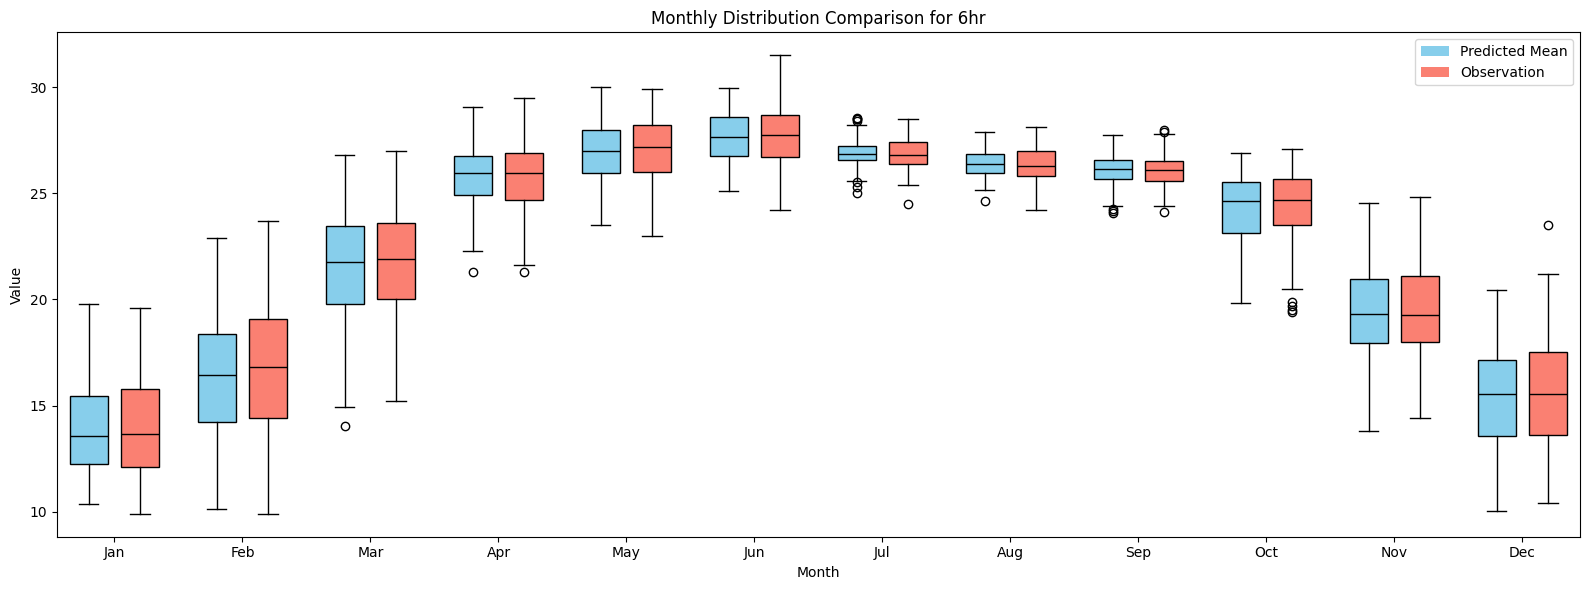

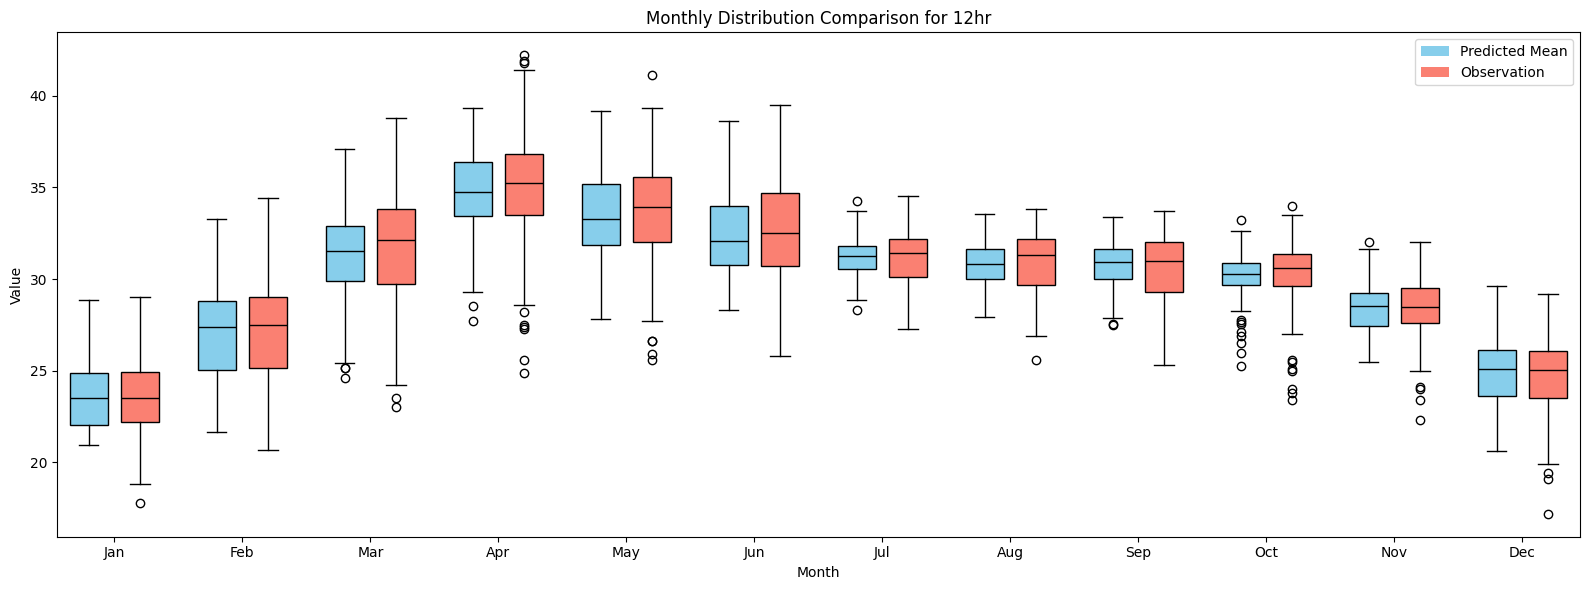

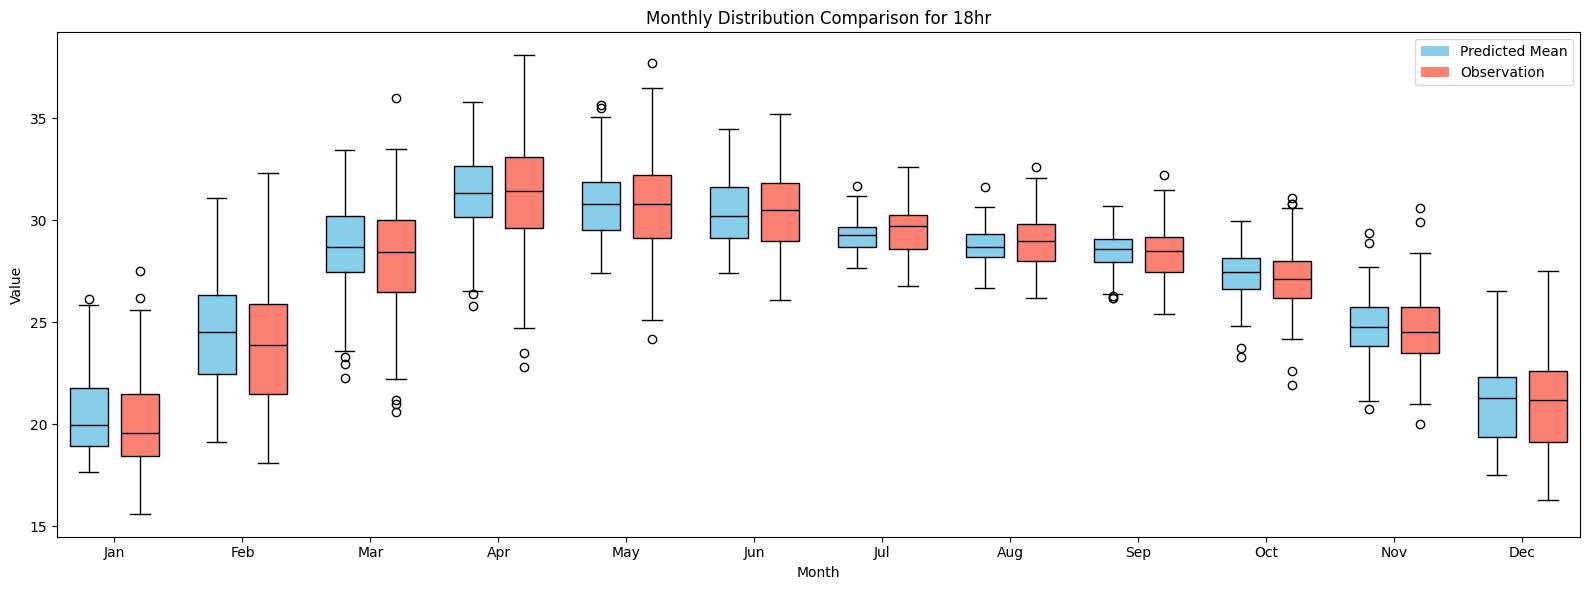

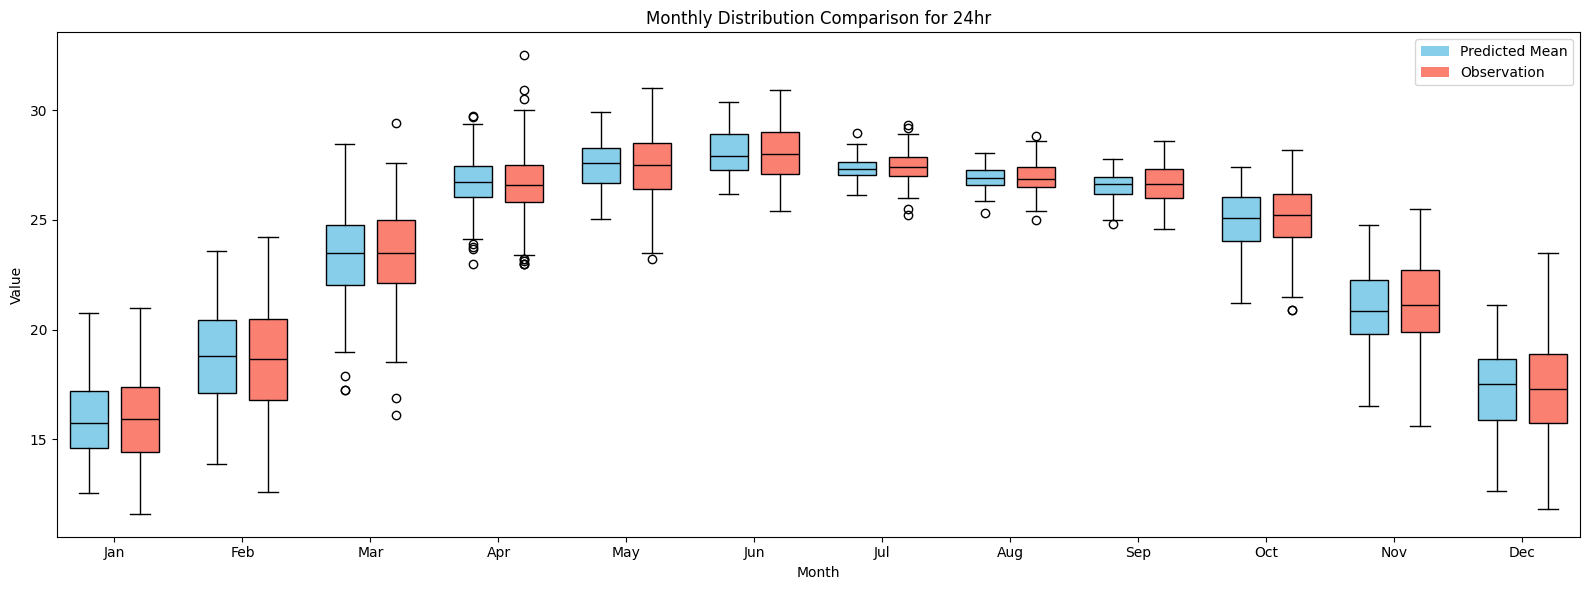

In [39]:
horizons = ['6hr', '12hr', '18hr', '24hr']
months = range(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

for horizon in horizons:
    pred_data = []
    test_data = []

    for m in months:
        pred_data.append(
            df_pred_kolkata[df_pred_kolkata.index.month == m][horizon].dropna()
        )
        test_data.append(
            pipe1.y_test[pipe1.y_test.index.month == m][horizon].dropna()
        )

    fig, ax = plt.subplots(figsize=(16, 6))

    positions_pred = np.arange(1, 13) * 2 - 0.4
    positions_test = np.arange(1, 13) * 2 + 0.4

    bp_pred = ax.boxplot(
        pred_data,
        positions=positions_pred,
        widths=0.6,
        patch_artist=True,
        boxprops=dict(facecolor='skyblue'),
        medianprops=dict(color='black')
    )

    bp_test = ax.boxplot(
        test_data,
        positions=positions_test,
        widths=0.6,
        patch_artist=True,
        boxprops=dict(facecolor='salmon'),
        medianprops=dict(color='black')
    )

    ax.set_xticks(np.arange(1, 13) * 2)
    ax.set_xticklabels(month_labels)
    ax.set_title(f'Monthly Distribution Comparison for {horizon}')
    ax.set_xlabel('Month')
    ax.set_ylabel('Value')

    # Custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='skyblue', label='Predicted Mean'),
        Patch(facecolor='salmon', label='Observation')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

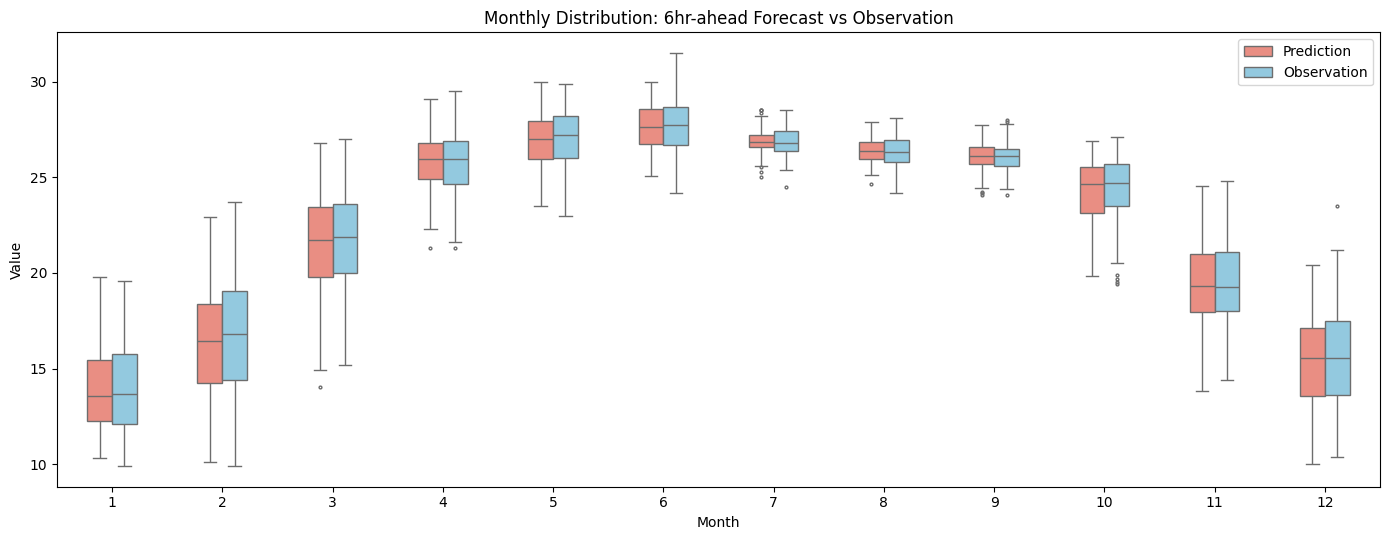

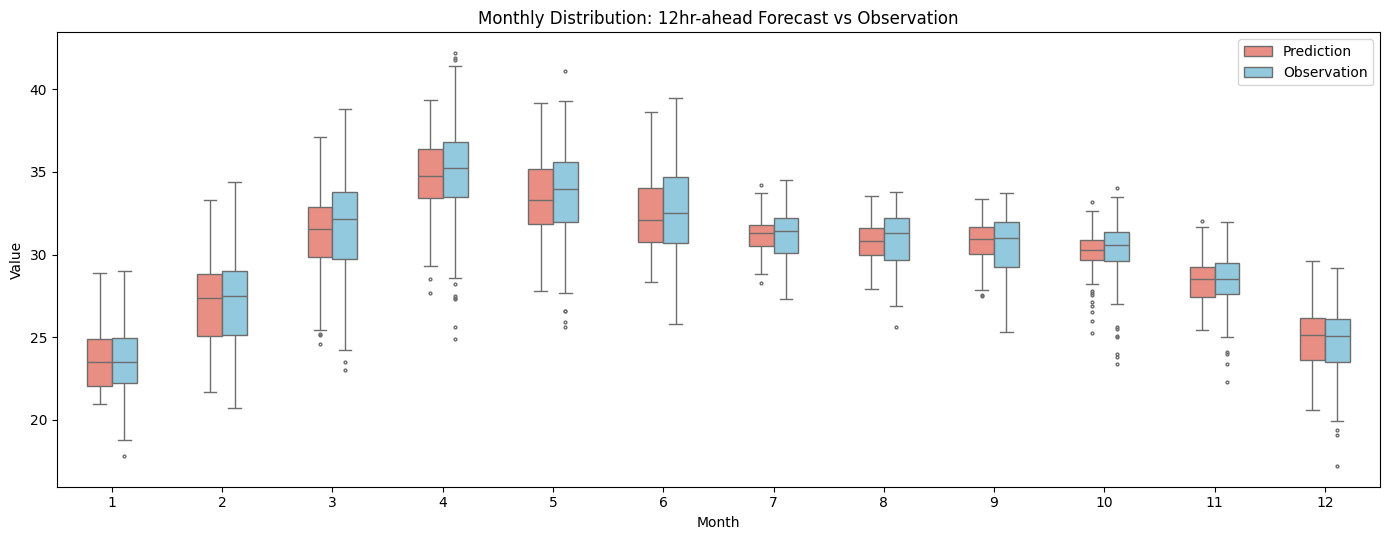

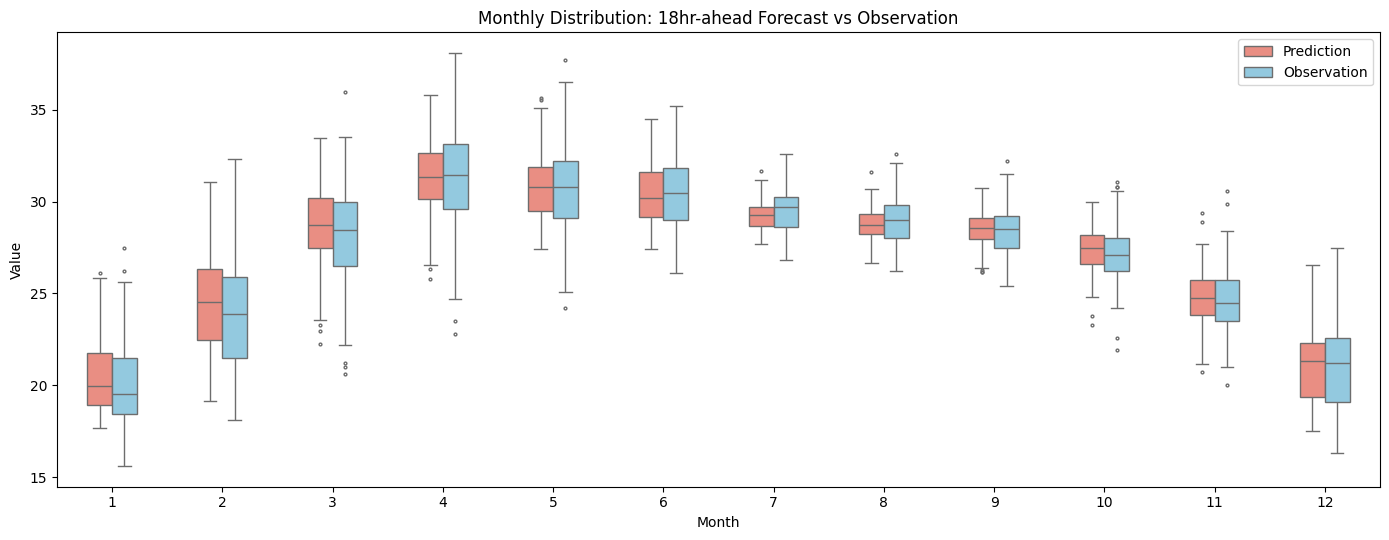

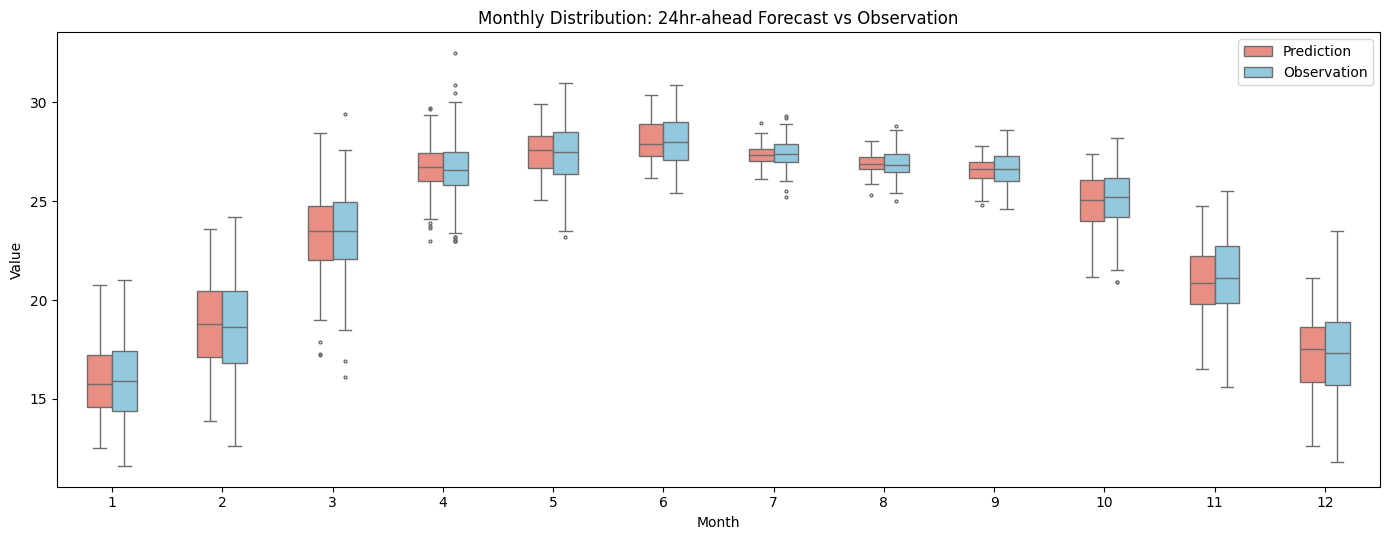

In [34]:
pred = df_pred_kolkata.copy()
obs = pipe1.y_test.copy()

pred['Month'] = pred.index.month
obs['Month'] = obs.index.month

pred['Source'] = 'Prediction'
obs['Source'] = 'Observation'

horizons = ['6hr', '12hr', '18hr', '24hr']
month_order = [1,2,3,4,5,6,7,8,9,10,11,12]

for horizon in horizons:
    # Convert to long format
    pred_long = pred[['Month', horizon, 'Source']].rename(columns={horizon: 'Value'})
    obs_long = obs[['Month', horizon, 'Source']].rename(columns={horizon: 'Value'})

    plot_df = pd.concat([pred_long, obs_long])

    plt.figure(figsize=(14, 5.5), dpi=100)

    sns.boxplot(
        data=plot_df,
        x='Month',
        y='Value',
        hue='Source',
        order=month_order,
        palette={'Prediction': 'salmon', 'Observation': 'skyblue'},
        width=0.45,
        fliersize=2
    )

    plt.title(f'Monthly Distribution: {horizon}-ahead Forecast vs Observation')
    plt.xlabel('Month')
    plt.ylabel('Value')
    plt.legend(title='')
    plt.tight_layout()
    plt.show()

## Plot

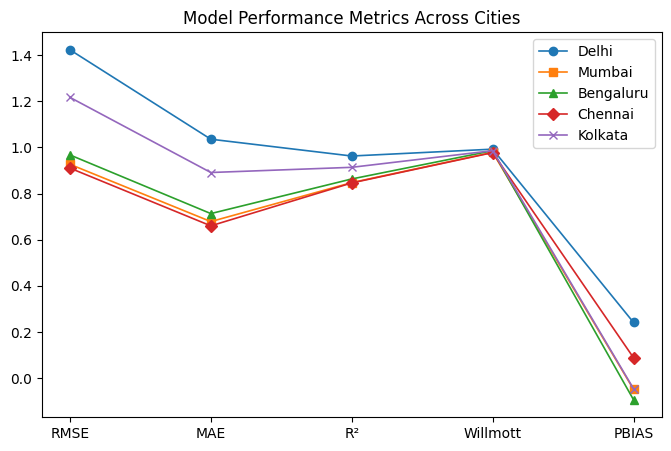

In [69]:
metrics = ['RMSE', 'MAE', 'R²', 'Willmott', 'PBIAS']
values_delhi = [results_delhi['rmse'], results_delhi['mae'], results_delhi['r2'], results_delhi['willmott'], results_delhi['pbias']]
values_mumbai = [results_mumbai['rmse'], results_mumbai['mae'], results_mumbai['r2'], results_mumbai['willmott'], results_mumbai['pbias']]
values_bengaluru = [results_bengaluru['rmse'], results_bengaluru['mae'], results_bengaluru['r2'], results_bengaluru['willmott'], results_bengaluru['pbias']]
values_chennai = [results_chennai['rmse'], results_chennai['mae'], results_chennai['r2'], results_chennai['willmott'], results_chennai['pbias']]
values_kolkata = [results_kolkata['rmse'], results_kolkata['mae'], results_kolkata['r2'], results_kolkata['willmott'], results_kolkata['pbias']]
plt.figure(figsize=(8,5))
plt.plot(metrics, values_delhi, marker='o', linewidth=1.2, label='Delhi')
plt.plot(metrics, values_mumbai, marker='s', linewidth=1.2, label='Mumbai')
plt.plot(metrics, values_bengaluru, marker='^', linewidth=1.2, label='Bengaluru')
plt.plot(metrics, values_chennai, marker='D', linewidth=1.2, label='Chennai')
plt.plot(metrics, values_kolkata, marker='x', linewidth=1.2, label='Kolkata')
plt.title('Model Performance Metrics Across Cities')
plt.legend()
plt.show()

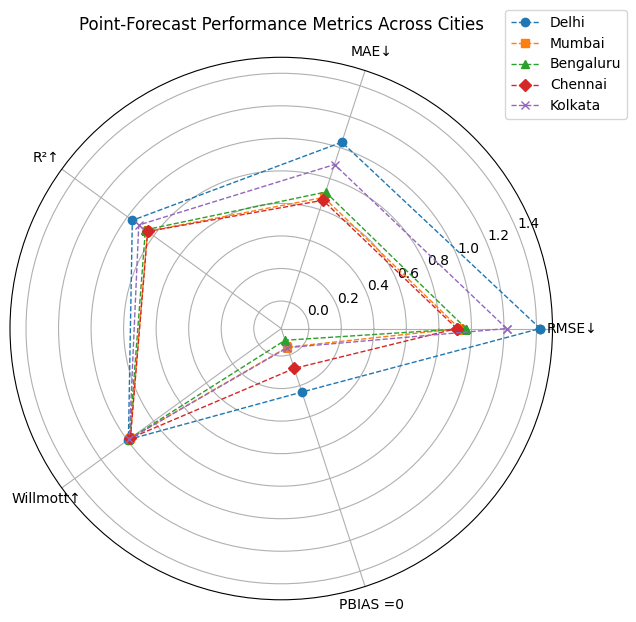

In [89]:
metrics = ['RMSE↓', 'MAE↓', 'R²↑', 'Willmott↑', 'PBIAS =0']
num_metrics = len(metrics)

# Close the loop
angles = np.linspace(0, 2*np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

def close(values):
    return values + values[:1]

values_delhi_c = close(values_delhi)
values_mumbai_c = close(values_mumbai)
values_bengaluru_c = close(values_bengaluru)
values_chennai_c = close(values_chennai)
values_kolkata_c = close(values_kolkata)

fig, ax = plt.subplots(figsize=(7,9), subplot_kw=dict(polar=True))

ax.plot(angles, values_delhi_c, marker='o', linewidth=1,  label='Delhi', linestyle='--')
ax.plot(angles, values_mumbai_c, marker='s', linewidth=1, label='Mumbai', linestyle='--')
ax.plot(angles, values_bengaluru_c, marker='^', linewidth=1, label='Bengaluru', linestyle='--')
ax.plot(angles, values_chennai_c, marker='D', linewidth=1, label='Chennai', linestyle='--')
ax.plot(angles, values_kolkata_c, marker='x', linewidth=1, label='Kolkata', linestyle='--')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)

ax.set_title('Point-Forecast Performance Metrics Across Cities', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.1))
plt.show()


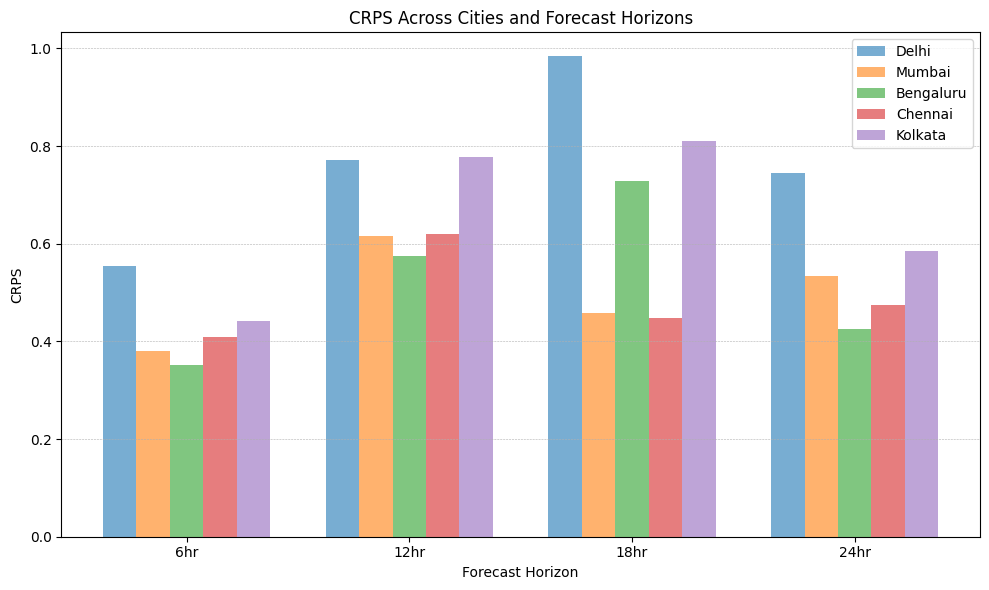

In [97]:
horizons = ['6hr', '12hr', '18hr', '24hr']
x = np.arange(len(horizons))
width = 0.15

plt.figure(figsize=(10,6))

plt.bar(x - 2*width, results_delhi['crps'], width, label='Delhi', alpha=0.6)
plt.bar(x - width,   results_mumbai['crps'], width, label='Mumbai', alpha=0.6)
plt.bar(x,           results_bengaluru['crps'], width, label='Bengaluru', alpha=0.6)
plt.bar(x + width,   results_chennai['crps'], width, label='Chennai', alpha=0.6)
plt.bar(x + 2*width, results_kolkata['crps'], width, label='Kolkata', alpha=0.6)

plt.xticks(x, horizons)
plt.xlabel('Forecast Horizon')
plt.ylabel('CRPS')
plt.title('CRPS Across Cities and Forecast Horizons')
plt.legend()
plt.grid(axis='y', which='major', linestyle='--', linewidth=0.4)
plt.tight_layout()
plt.show()